In [ ]:
import sys
sys.path.append('../')

# Prediction Pipeline Benchmark

This notebook benchmarks the satellite prediction pipeline performance with random geographical locations, timestamps, and synthetic doppler data.

## Section 1: Import Required Libraries

In [137]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

# Import dopplerguesser modules
from dopplerguesser.predict.fetch_tles import fetch_tles
from dopplerguesser.predict.filters import (
    filter_debris, filter_by_epoch, filter_constellations,
    filter_geostationary, filter_heo, filter_visibility, filter_by_doppler
)
from dopplerguesser.predict.matcher import score_candidates
from dopplerguesser.predict.observer import Observer
from dopplerguesser.predict.satellite import Satellite
from dopplerguesser.misc.constants import C

## Section 2: Setup Test Configuration

In [ ]:
# Configuration parameters for prediction pipeline
pipeline_config = {
    'filter_debris': True,
    'filter_by_epoch': True,
    'max_tle_age_days': 14,
    'filter_constellations': True,
    'filter_constellations_list': 'starlink,oneweb',
    'filter_geostationary': True,
    'filter_heo': True,
    'filter_heo_threshold': 0.25,
    'filter_visibility_min_elevation': 0.0,
    'filter_doppler': False,
    'filter_doppler_threshold': 2000,
    'propagation_cache_duration': 1000,
    'propagation_cache_step': 1,
}

# Center frequency for doppler calculations (2.4 GHz)
center_freq = 2.4e9

print("Configuration loaded:")
for key, value in pipeline_config.items():
    print(f"  {key}: {value}")

Configuration loaded:
  filter_debris: True
  filter_by_epoch: True
  max_tle_age_days: 14
  filter_constellations: True
  filter_constellations_list: starlink,oneweb
  filter_geostationary: True
  filter_heo: True
  filter_heo_threshold: 0.25
  filter_visibility_min_elevation: 0.0
  filter_doppler: True
  filter_doppler_threshold: 2000
  propagation_cache_duration: 1000
  propagation_cache_step: 1


## Section 3: Generate Random Test Data

In [139]:
# Generate 10 random geographical locations
num_locations = 10
random.seed(42)
np.random.seed(42)

locations = []
for i in range(num_locations):
    lat = random.uniform(-60, 60)  # Latitude -60 to 60 degrees
    lon = random.uniform(-180, 180)  # Longitude -180 to 180 degrees
    alt = random.uniform(0, 2000)  # Altitude 0-2000 meters
    locations.append((lat, lon, alt))

print(f"Generated {len(locations)} random locations:")
for i, (lat, lon, alt) in enumerate(locations):
    print(f"  Location {i+1}: lat={lat:.2f}°, lon={lon:.2f}°, alt={alt:.1f}m")

Generated 10 random locations:
  Location 1: lat=16.73°, lon=-171.00°, alt=550.1m
  Location 2: lat=-33.21°, lon=85.13°, alt=1353.4m
  Location 3: lat=47.06°, lon=-148.70°, alt=843.8m
  Location 4: lat=-56.42°, lon=-101.29°, alt=1010.7m
  Location 5: lat=-56.82°, lon=-108.42°, alt=1299.8m
  Location 6: lat=5.39°, lon=-100.64°, alt=1178.5m
  Location 7: lat=37.13°, lon=-177.66°, alt=1611.6m
  Location 8: lat=23.78°, lon=-57.51°, alt=311.0m
  Location 9: lat=54.87°, lon=-58.83°, alt=185.5m
  Location 10: lat=-48.39°, lon=125.10°, alt=1207.5m


In [140]:
# Generate 10 random time offsets from now to 10 days in the future
num_timestamps = 10
now = datetime.utcnow()
max_offset_seconds = 10 * 24 * 3600  # 10 days in seconds

time_offsets = []
for i in range(num_timestamps):
    offset_seconds = random.uniform(0, max_offset_seconds)
    timestamp = now + timedelta(seconds=offset_seconds)
    unix_timestamp = timestamp.timestamp()
    time_offsets.append((unix_timestamp, offset_seconds / 86400))  # Unix timestamp and days offset

print(f"\nGenerated {len(time_offsets)} random timestamps:")
for i, (unix_ts, days_offset) in enumerate(time_offsets):
    print(f"  Timestamp {i+1}: +{days_offset:.2f} days (Unix: {unix_ts:.0f})")


Generated 10 random timestamps:
  Timestamp 1: +8.07 days (Unix: 1779186481)
  Timestamp 2: +7.30 days (Unix: 1779119610)
  Timestamp 3: +5.36 days (Unix: 1778952423)
  Timestamp 4: +9.73 days (Unix: 1779329894)
  Timestamp 5: +3.79 days (Unix: 1778816176)
  Timestamp 6: +5.52 days (Unix: 1778966085)
  Timestamp 7: +8.29 days (Unix: 1779205728)
  Timestamp 8: +6.19 days (Unix: 1779023523)
  Timestamp 9: +8.62 days (Unix: 1779233637)
  Timestamp 10: +5.77 days (Unix: 1778987954)


In [141]:
# Generate synthetic doppler measurement data (random garbage)
def generate_synthetic_doppler(num_points=50, center_freq=2.4e9):
    """Generate random doppler measurement data"""
    times = np.linspace(0, 100, num_points)  # 100 seconds of data
    # Random doppler shifts with some structure
    shifts = np.random.normal(0, 500, num_points) + 1000 * np.sin(times / 10)
    measurements = [(t, center_freq + s) for t, s in zip(times, shifts)]
    return measurements

sample_doppler = generate_synthetic_doppler()
print(f"\nGenerated synthetic doppler data (sample first 5 points):")
for i, (t, f) in enumerate(sample_doppler[:5]):
    print(f"  Point {i+1}: time={t:.2f}s, freq={f:.0f} Hz")


Generated synthetic doppler data (sample first 5 points):
  Point 1: time=0.00s, freq=2400000248 Hz
  Point 2: time=2.04s, freq=2400000134 Hz
  Point 3: time=4.08s, freq=2400000721 Hz
  Point 4: time=6.12s, freq=2400001336 Hz
  Point 5: time=8.16s, freq=2400000612 Hz


## Section 4: Initialize Observer and Fetch TLEs

In [142]:
from tqdm import tqdm
observers = {}
tle_data = {}
init_times = {}

print("Initializing observers and fetching TLEs...\n")

for loc_idx, (lat, lon, alt) in tqdm(enumerate(locations), total=len(locations)):
    for time_idx, (unix_ts, _) in tqdm(enumerate(time_offsets), total=len(time_offsets)):
        key = (loc_idx, time_idx)
        # Create observer
        start = time.time()
        observer = Observer(lat=lat, lon=lon, alt=alt)
        observers[key] = observer
        init_times[f"observer_{loc_idx}_{time_idx}"] = time.time() - start
        
        # Fetch TLEs (Satellite creation happens here)
        start = time.time()
        try:
            satellites = fetch_tles(unix_ts)
            tle_data[key] = satellites
            init_times[f"fetch_tle_{loc_idx}_{time_idx}"] = time.time() - start
            
        except Exception as e:
            print(f"Warning: Failed to fetch TLEs for location {loc_idx}, time {time_idx}: {e}")
            tle_data[key] = []
            init_times[f"fetch_tle_{loc_idx}_{time_idx}"] = None
            init_times[f"propagate_{loc_idx}_{time_idx}"] = None

print("Initialization complete.")
print(f"Total observer-timestamp combinations: {len(observers)}")

Initializing observers and fetching TLEs...



100%|██████████| 10/10 [00:38<00:00,  3.82s/it]

Initialization complete.
Total observer-timestamp combinations: 100


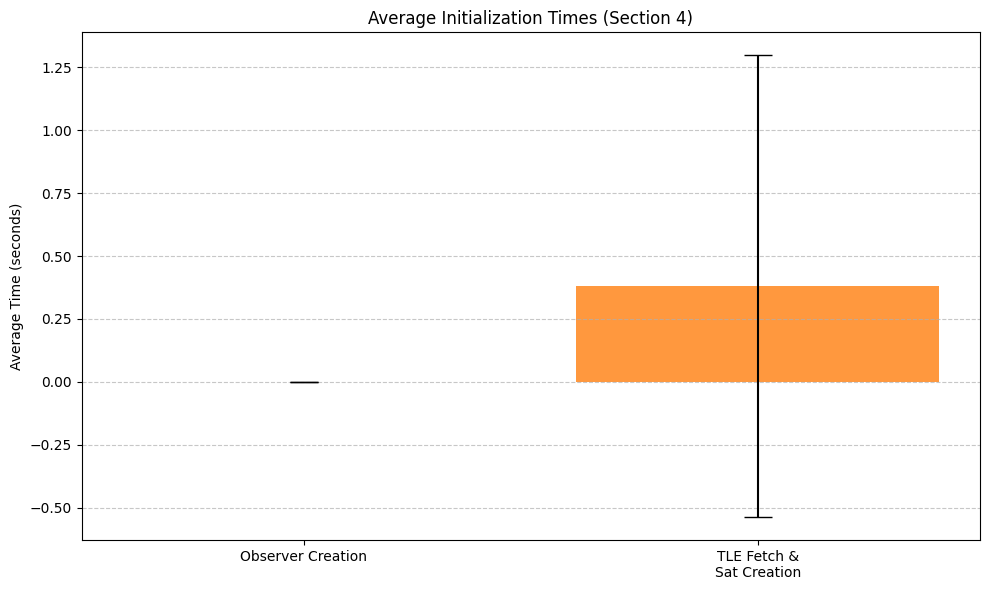

Initialization Timing Summary:
  Average Observer Creation: 0.00021s (std: 0.00146)
  Average TLE Fetch & Sat Creation: 0.38015s (std: 0.91621)


In [143]:
# Extract timing data for visualization
obs_times = [v for k, v in init_times.items() if k.startswith('observer_') and v is not None]
fetch_times = [v for k, v in init_times.items() if k.startswith('fetch_tle_') and v is not None]

# Calculate means and standard deviations
means = [np.mean(obs_times), np.mean(fetch_times)]
std_devs = [np.std(obs_times), np.std(fetch_times)]
labels = ['Observer Creation', 'TLE Fetch &\nSat Creation']

# Visualize Section 4 timings
plt.figure(figsize=(10, 6))
plt.bar(labels, means, yerr=std_devs, capsize=10, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
plt.ylabel('Average Time (seconds)')
plt.title('Average Initialization Times (Section 4)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Initialization Timing Summary:")
print(f"  Average Observer Creation: {means[0]:.5f}s (std: {std_devs[0]:.5f})")
print(f"  Average TLE Fetch & Sat Creation: {means[1]:.5f}s (std: {std_devs[1]:.5f})")

## Section 5: Run Prediction Pipeline with Timing

In [144]:
def run_prediction_pipeline(satellites: List[Satellite], observer: Observer, 
                           unix_ts: float, config: Dict, doppler_data: List[Tuple]):
    """
    Run the full prediction pipeline and return timing data
    """
    timing = {}
    satellites_after_filter = {}
    
    # Debris filter
    start = time.time()
    if config['filter_debris']:
        satellites = filter_debris(satellites)
    timing['debris_filter'] = time.time() - start
    satellites_after_filter['debris'] = len(satellites)
    
    # Epoch filter
    start = time.time()
    if config['filter_by_epoch'] and config['max_tle_age_days'] > 0:
        satellites = filter_by_epoch(satellites, maxage=config['max_tle_age_days'])
    timing['epoch_filter'] = time.time() - start
    satellites_after_filter['epoch'] = len(satellites)
    
    # Constellation filter
    start = time.time()
    if config['filter_constellations']:
        constellations = [c.strip().lower() for c in config['filter_constellations_list'].split(",") if c.strip()]
        if constellations:
            satellites = filter_constellations(satellites, constellations)
    timing['constellation_filter'] = time.time() - start
    satellites_after_filter['constellation'] = len(satellites)
    
    # Geostationary filter
    start = time.time()
    satellites = filter_geostationary(satellites)
    timing['geostationary_filter'] = time.time() - start
    satellites_after_filter['geostationary'] = len(satellites)
    
    # HEO filter
    start = time.time()
    if config['filter_heo']:
        satellites = filter_heo(satellites, eccentricity_threshold=config['filter_heo_threshold'])
    timing['heo_filter'] = time.time() - start
    satellites_after_filter['heo'] = len(satellites)
    
    # Visibility filter
    start = time.time()
    satellites = filter_visibility(satellites, observer, unix_ts, min_elevation=config['filter_visibility_min_elevation'])
    timing['visibility_filter'] = time.time() - start
    satellites_after_filter['visibility'] = len(satellites)
    
    if len(satellites) == 0:
        return timing, satellites_after_filter, 0, 0
    
    # Doppler filter
    start = time.time()
    if config['filter_doppler'] and len(doppler_data) > 0:
        first_freq = doppler_data[0][1]
        satellites = filter_by_doppler(satellites, observer, unix_ts, center_freq, first_freq, 
                                       threshold=config['filter_doppler_threshold'])
    timing['doppler_filter'] = time.time() - start
    satellites_after_filter['doppler'] = len(satellites)
    
    if len(satellites) == 0:
        return timing, satellites_after_filter, 0, 0
    
    # Observer track computation
    start = time.time()
    observer.compute_track(unix_ts, duration=config['propagation_cache_duration'], 
                          step=config['propagation_cache_step'])
    timing['observer_track'] = time.time() - start
    
    # Satellite propagation to t0
    start = time.time()
    for sat in satellites:
        sat.compute_initial_state(unix_ts)
    timing['sat_propagation_t0'] = time.time() - start
    
    # Satellite track computation
    start = time.time()
    for sat in satellites:
        sat.compute_track(unix_ts, duration=config['propagation_cache_duration'],
                         step=config['propagation_cache_step'])
    timing['sat_track_computation'] = time.time() - start
    
    # Scoring
    start = time.time()
    measurements = [(t, f) for t, f in doppler_data]
    scored = score_candidates(satellites, measurements, center_freq, observer)
    timing['scoring'] = time.time() - start
    
    return timing, satellites_after_filter, len(satellites), len(scored)

print("Pipeline function defined successfully")

Pipeline function defined successfully


In [145]:
print("Running prediction pipeline benchmarks...\n")

benchmark_results = []
total_combinations = len(locations) * len(time_offsets)
completed = 0

for loc_idx, (lat, lon, alt) in enumerate(locations):
    for time_idx, (unix_ts, days_offset) in enumerate(time_offsets):
        key = (loc_idx, time_idx)
        completed += 1
        
        try:
            observer = observers[key]
            satellites = tle_data[key]
            
            if len(satellites) == 0:
                print(f"[{completed}/{total_combinations}] Location {loc_idx+1}, Time {time_idx+1}: No TLE data")
                continue
            
            # Generate doppler data for this scenario
            doppler_data = generate_synthetic_doppler(num_points=50, center_freq=center_freq)
            
            # Run pipeline
            start_total = time.time()
            timing, sat_counts, final_candidates, scored_count = run_prediction_pipeline(
                satellites, observer, unix_ts, pipeline_config, doppler_data
            )
            total_time = time.time() - start_total
            
            # Record results
            result = {
                'location_idx': loc_idx,
                'time_idx': time_idx,
                'latitude': lat,
                'longitude': lon,
                'altitude': alt,
                'days_offset': days_offset,
                'total_time': total_time,
                **timing,
                **{f'sat_after_{k}': v for k, v in sat_counts.items()},
                'initial_satellites': len(satellites),
                'final_candidates': final_candidates,
                'scored_count': scored_count,
            }
            benchmark_results.append(result)
            
            print(f"[{completed}/{total_combinations}] Location {loc_idx+1}, Time {time_idx+1}: "
                  f"Total={total_time:.3f}s, Candidates={final_candidates}, Scored={scored_count}")
            
        except Exception as e:
            print(f"[{completed}/{total_combinations}] Location {loc_idx+1}, Time {time_idx+1}: Error - {e}")
            continue

print(f"\nCompleted {len(benchmark_results)} successful benchmarks out of {total_combinations} combinations")

Running prediction pipeline benchmarks...

[1/100] Location 1, Time 1: Total=0.191s, Candidates=4, Scored=4
[2/100] Location 1, Time 2: Total=0.142s, Candidates=1, Scored=1
[3/100] Location 1, Time 3: Total=0.173s, Candidates=1, Scored=1
[4/100] Location 1, Time 4: Total=0.187s, Candidates=4, Scored=4
[5/100] Location 1, Time 5: Total=0.156s, Candidates=2, Scored=2
[6/100] Location 1, Time 6: Total=0.186s, Candidates=3, Scored=3
[7/100] Location 1, Time 7: Total=0.133s, Candidates=1, Scored=1
[8/100] Location 1, Time 8: Total=0.174s, Candidates=3, Scored=3
[9/100] Location 1, Time 9: Total=0.191s, Candidates=4, Scored=4
[10/100] Location 1, Time 10: Total=0.153s, Candidates=3, Scored=3
[11/100] Location 2, Time 1: Total=0.165s, Candidates=3, Scored=3
[12/100] Location 2, Time 2: Total=0.216s, Candidates=6, Scored=6
[13/100] Location 2, Time 3: Total=0.125s, Candidates=1, Scored=1
[14/100] Location 2, Time 4: Total=0.196s, Candidates=4, Scored=4
[15/100] Location 2, Time 5: Total=0.221s

## Section 6: Analyze and Visualize Results

In [146]:
# Create DataFrame from results
df = pd.DataFrame(benchmark_results)

print("Benchmark Results Summary")
print("=" * 80)
print(f"\nTotal successful runs: {len(df)}")
print(f"\nTiming Statistics (in seconds):")
print(df[['total_time', 'debris_filter', 'epoch_filter', 'constellation_filter', 'geostationary_filter', 'heo_filter', 'visibility_filter', 'doppler_filter']].describe())

print(f"\nCandidate Statistics:")
print(f"  Initial satellites - Mean: {df['initial_satellites'].mean():.1f}, "
      f"Median: {df['initial_satellites'].median():.1f}")
print(f"  Final candidates - Mean: {df['final_candidates'].mean():.1f}, "
      f"Median: {df['final_candidates'].median():.1f}")
print(f"  Scored - Mean: {df['scored_count'].mean():.1f}, "
      f"Median: {df['scored_count'].median():.1f}")

Benchmark Results Summary

Total successful runs: 100

Timing Statistics (in seconds):
       total_time  debris_filter  epoch_filter  constellation_filter  \
count  100.000000     100.000000    100.000000            100.000000   
mean     0.184722       0.007222      0.010447              0.003550   
std      0.029020       0.003614      0.001942              0.000164   
min      0.125187       0.004675      0.009092              0.003385   
25%      0.162880       0.004907      0.009415              0.003433   
50%      0.180581       0.005275      0.009633              0.003500   
75%      0.201064       0.008980      0.010341              0.003602   
max      0.277332       0.029292      0.017836              0.004090   

       geostationary_filter  heo_filter  visibility_filter  doppler_filter  
count            100.000000  100.000000         100.000000      100.000000  
mean               0.006263    0.000382           0.096717        0.003051  
std                0.003261    0.

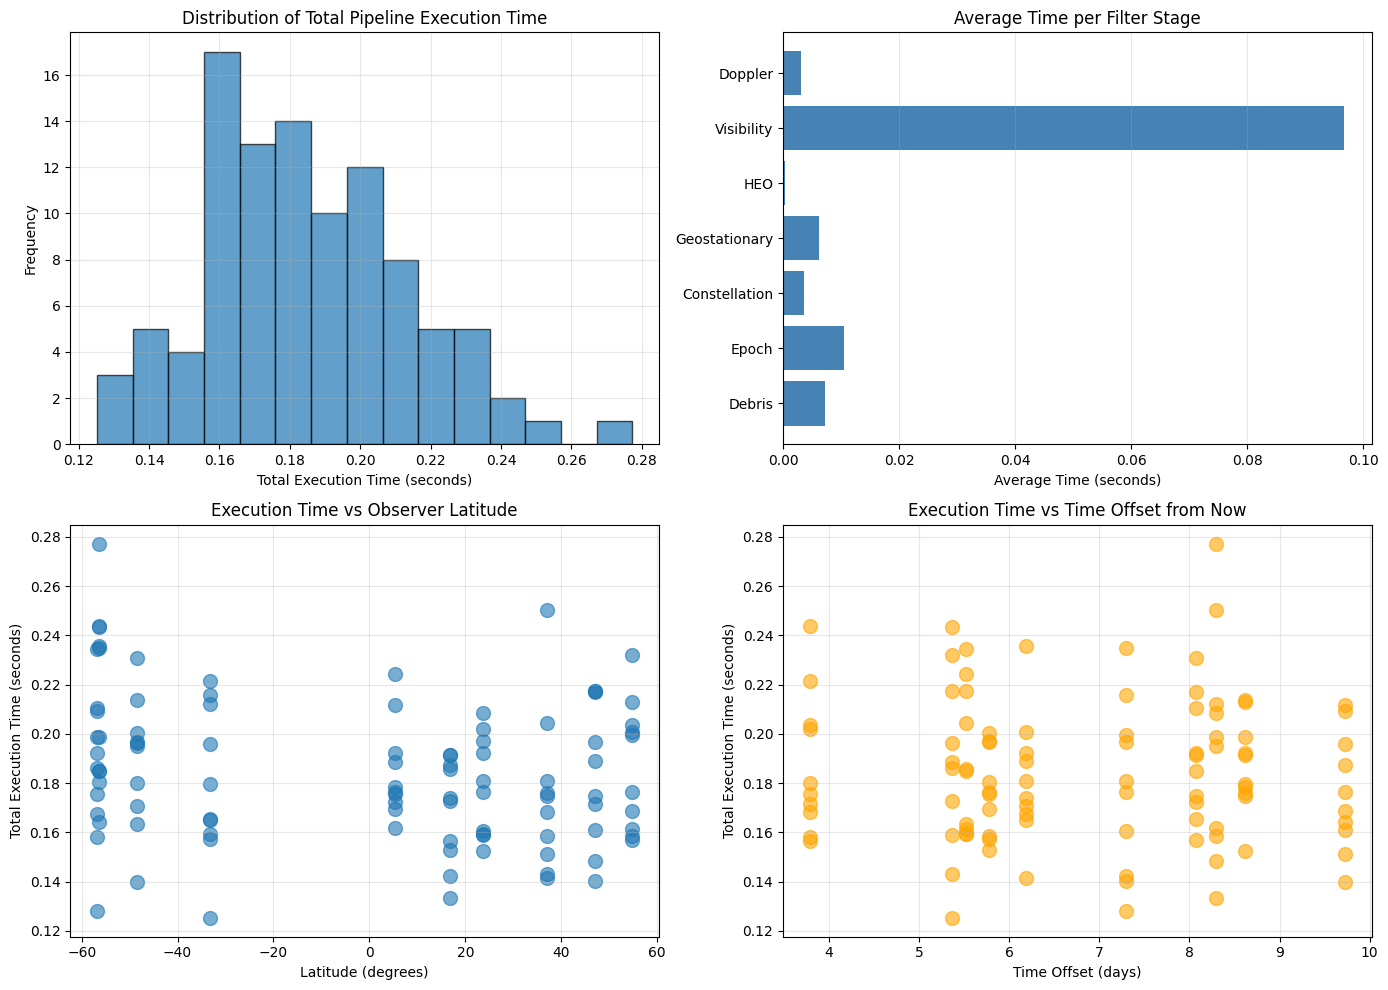

In [147]:
# Visualization 1: Total execution time distribution
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.hist(df['total_time'], bins=15, edgecolor='black', alpha=0.7)
plt.xlabel('Total Execution Time (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Total Pipeline Execution Time')
plt.grid(True, alpha=0.3)

# Visualization 2: Filter stage breakdown
plt.subplot(2, 2, 2)
filter_columns = ['debris_filter', 'epoch_filter', 'constellation_filter', 
                  'geostationary_filter', 'heo_filter', 'visibility_filter', 'doppler_filter']
filter_means = [df[col].mean() for col in filter_columns]
filter_names = ['Debris', 'Epoch', 'Constellation', 'Geostationary', 'HEO', 'Visibility', 'Doppler']
bars = plt.barh(filter_names, filter_means, color='steelblue')
plt.xlabel('Average Time (seconds)')
plt.title('Average Time per Filter Stage')
plt.grid(True, alpha=0.3, axis='x')

# Visualization 3: Execution time vs latitude
plt.subplot(2, 2, 3)
plt.scatter(df['latitude'], df['total_time'], alpha=0.6, s=100)
plt.xlabel('Latitude (degrees)')
plt.ylabel('Total Execution Time (seconds)')
plt.title('Execution Time vs Observer Latitude')
plt.grid(True, alpha=0.3)

# Visualization 4: Execution time vs time offset
plt.subplot(2, 2, 4)
plt.scatter(df['days_offset'], df['total_time'], alpha=0.6, s=100, color='orange')
plt.xlabel('Time Offset (days)')
plt.ylabel('Total Execution Time (seconds)')
plt.title('Execution Time vs Time Offset from Now')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [148]:
# Detailed statistics by location
print("\nPerformance by Location:")
print("=" * 80)
location_stats = df.groupby('location_idx').agg({
    'total_time': ['count', 'mean', 'std', 'min', 'max'],
    'initial_satellites': 'mean',
    'final_candidates': 'mean',
    'scored_count': 'mean'
}).round(3)

for col_name in location_stats.columns:
    location_stats[col_name] = location_stats[col_name].round(3)

print(location_stats)


Performance by Location:
             total_time                             initial_satellites  \
                  count   mean    std    min    max               mean   
location_idx                                                             
0                    10  0.169  0.021  0.133  0.191            15760.0   
1                    10  0.180  0.031  0.125  0.221            15760.0   
2                    10  0.183  0.029  0.140  0.217            15760.0   
3                    10  0.215  0.037  0.164  0.277            15760.0   
4                    10  0.186  0.030  0.128  0.235            15760.0   
5                    10  0.185  0.020  0.162  0.224            15760.0   
6                    10  0.175  0.033  0.141  0.250            15760.0   
7                    10  0.179  0.020  0.153  0.209            15760.0   
8                    10  0.187  0.026  0.157  0.232            15760.0   
9                    10  0.189  0.026  0.140  0.231            15760.0   

           

In [149]:
# Detailed statistics by time offset
print("\nPerformance by Time Offset:")
print("=" * 80)
time_stats = df.groupby('time_idx').agg({
    'total_time': ['count', 'mean', 'std', 'min', 'max'],
    'initial_satellites': 'mean',
    'final_candidates': 'mean',
    'scored_count': 'mean',
    'days_offset': 'first'
}).round(3)

for col_name in time_stats.columns:
    time_stats[col_name] = time_stats[col_name].round(3)

print(time_stats)


Performance by Time Offset:
         total_time                             initial_satellites  \
              count   mean    std    min    max               mean   
time_idx                                                             
0                10  0.190  0.024  0.157  0.231            15760.0   
1                10  0.178  0.035  0.128  0.235            15760.0   
2                10  0.186  0.038  0.125  0.244            15760.0   
3                10  0.177  0.024  0.140  0.212            15760.0   
4                10  0.188  0.029  0.156  0.244            15760.0   
5                10  0.190  0.029  0.159  0.235            15760.0   
6                10  0.194  0.046  0.133  0.277            15760.0   
7                10  0.182  0.025  0.141  0.236            15760.0   
8                10  0.187  0.019  0.153  0.214            15760.0   
9                10  0.176  0.017  0.153  0.201            15760.0   

         final_candidates scored_count days_offset  
       

In [150]:
# Export detailed results to CSV
output_csv = 'pipeline_benchmark_detailed_results.csv'

# Summary statistics export
summary_stats = {
    'Metric': [
        'Total Runs',
        'Mean Total Time (s)',
        'Median Total Time (s)',
        'Std Dev Total Time (s)',
        'Min Total Time (s)',
        'Max Total Time (s)',
        'Mean Initial Satellites',
        'Mean Final Candidates',
        'Mean Scored Results',
    ],
    'Value': [
        len(df),
        f"{df['total_time'].mean():.4f}",
        f"{df['total_time'].median():.4f}",
        f"{df['total_time'].std():.4f}",
        f"{df['total_time'].min():.4f}",
        f"{df['total_time'].max():.4f}",
        f"{df['initial_satellites'].mean():.1f}",
        f"{df['final_candidates'].mean():.1f}",
        f"{df['scored_count'].mean():.1f}",
    ]
}

summary_df = pd.DataFrame(summary_stats)
summary_csv = 'pipeline_benchmark_summary.csv'

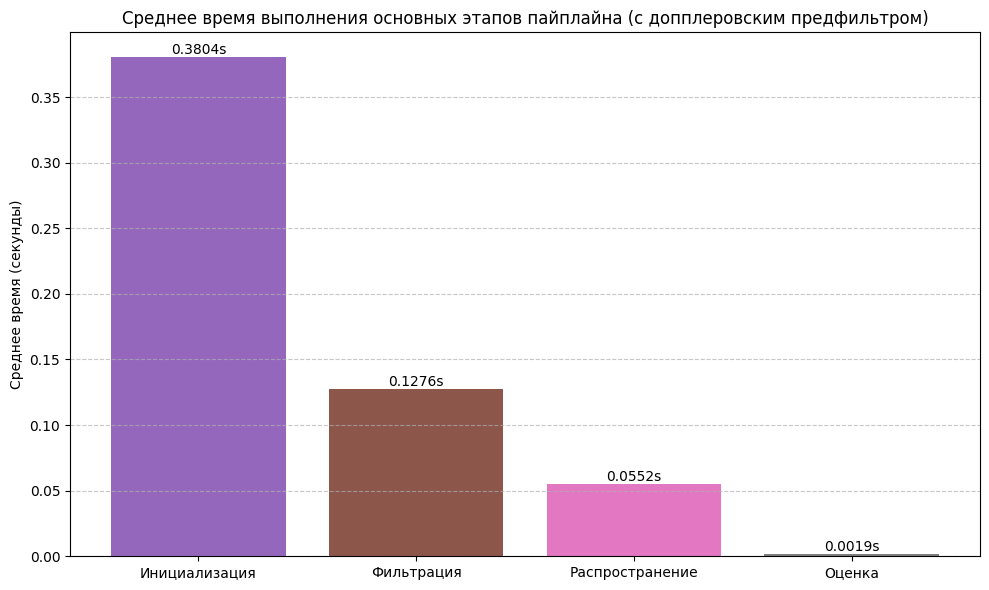

Pipeline Major Step Averages:
  Инициализация: 0.3804s
  Фильтрация: 0.1276s
  Распространение: 0.0552s
  Оценка: 0.0019s
  Total Average Pipeline Time: 0.5651s


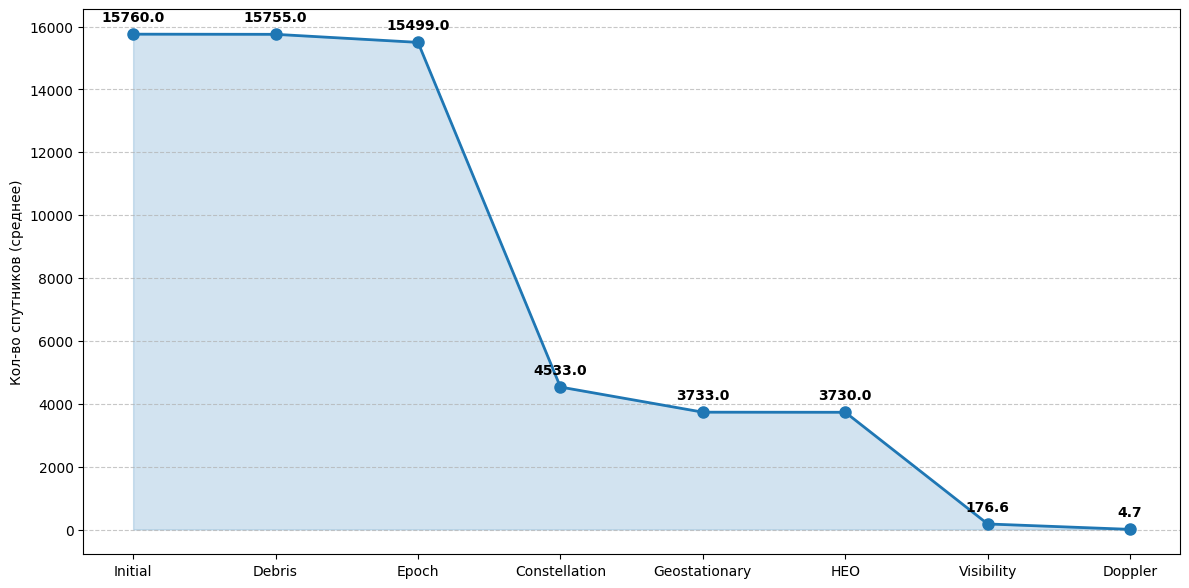


Satellite Filtering Attrition:
  Initial: 15760.0 satellites left
  Debris: 15755.0 satellites left
  Epoch: 15499.0 satellites left
  Constellation: 4533.0 satellites left
  Geostationary: 3733.0 satellites left
  HEO: 3730.0 satellites left
  Visibility: 176.6 satellites left
  Doppler: 4.7 satellites left


In [ ]:
# Summary of all pipeline major steps
# Calculate overall initialization time
init_time_avg = np.mean(obs_times) + np.mean(fetch_times)

# Summarize filtering times
filter_cols = ['debris_filter', 'epoch_filter', 'constellation_filter', 
               'geostationary_filter', 'heo_filter', 'visibility_filter', 'doppler_filter']
filter_time_avg = df[filter_cols].sum(axis=1).mean()

# Summarize propagation times
prop_cols = ['observer_track', 'sat_propagation_t0', 'sat_track_computation']
prop_time_avg = df[prop_cols].sum(axis=1).mean()

# Summarize scoring times
scoring_time_avg = df['scoring'].mean()

steps = ['Инициализация', 'Фильтрация', 'Распространение', 'Оценка']
avg_times = [init_time_avg, filter_time_avg, prop_time_avg, scoring_time_avg]

plt.figure(figsize=(10, 6))
bars = plt.bar(steps, avg_times, color=['#9467bd', '#8c564b', '#e377c2', '#7f7f7f'])
plt.ylabel('Среднее время (секунды)')
plt.title('Среднее время выполнения основных этапов пайплайна (без допплеровского предфильтра)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}s", ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Pipeline Major Step Averages:")
for step, avg_t in zip(steps, avg_times):
    print(f"  {step}: {avg_t:.4f}s")
print(f"  Total Average Pipeline Time: {sum(avg_times):.4f}s")

# --- Satellite Attrition Analysis ---
filter_stages = [
    'Initial', 'Debris', 'Epoch', 'Constellation', 
    'Geostationary', 'HEO', 'Visibility', 'Doppler'
]

# Calculate averages (handling runs smoothly by checking column existence)
avg_sats = [
    df['initial_satellites'].mean() if 'initial_satellites' in df else 0,
    df['sat_after_debris'].mean() if 'sat_after_debris' in df else 0,
    df['sat_after_epoch'].mean() if 'sat_after_epoch' in df else 0,
    df['sat_after_constellation'].mean() if 'sat_after_constellation' in df else 0,
    df['sat_after_geostationary'].mean() if 'sat_after_geostationary' in df else 0,
    df['sat_after_heo'].mean() if 'sat_after_heo' in df else 0,
    df['sat_after_visibility'].mean() if 'sat_after_visibility' in df else 0,
    df['sat_after_doppler'].mean() if 'sat_after_doppler' in df else 0
]

plt.figure(figsize=(12, 6))
plt.plot(filter_stages, avg_sats, marker='o', linestyle='-', linewidth=2, markersize=8, color='#1f77b4')
plt.fill_between(filter_stages, avg_sats, alpha=0.2, color='#1f77b4')
plt.ylabel('Кол-во спутников (среднее)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate each point's value cleanly
for i, val in enumerate(avg_sats):
    if pd.notna(val) and val > 0:
        plt.text(i, val + (max(avg_sats)*0.02), f"{val:.1f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSatellite Filtering Attrition:")
for stage, count in zip(filter_stages, avg_sats):
    print(f"  {stage}: {count:.1f} satellites left")